In [259]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional
from collections import defaultdict

https://github.com/jolpica/jolpica-f1?tab=readme-ov-file

The value of the positionText attribute is either an integer (finishing position), “R” (retired), “D” (disqualified), “E” (excluded), “W” (withdrawn), “F” (failed to qualify) or “N” (not classified). A grid position value of ‘0’ indicates the driver started from the pit lane. https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020/discussion/311490

In [260]:
def load_model_data(years: Optional[list[int]] = None):
    results = pd.read_csv('data/results.csv')
    races = pd.read_csv('data/races.csv')

    if years:
        races = races.loc[races['year'].isin(years)]
        
    results = results.loc[results['raceId'].isin(races['raceId'])]
    results = pd.merge(results, races[['raceId', 'year', 'name', 'round']], on='raceId', how='left')

    return results

In [261]:
drivers = pd.read_csv('data/drivers.csv')

In [262]:
years = [2019, 2020, 2021, 2022, 2023]
results = load_model_data(years)

In [263]:
results['position'] = results['position'].map(lambda x: int(x) if x.isdigit() else 0)

In [264]:
driver = 1
drivers[drivers['driverId'] == driver]

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton


In [265]:
driver_results = results.loc[results['driverId'] == driver]
driver_results['cumulative_points'] = driver_results.sort_values('round').groupby('year')['points'].cumsum()

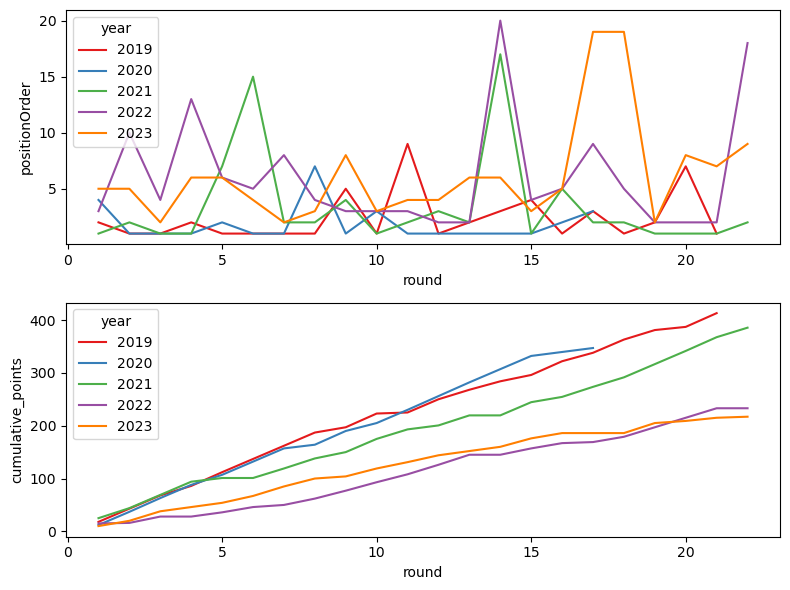

In [266]:
fig, axs = plt.subplots(2, 1, figsize=(8, 6))
sns.lineplot(x='round', y='positionOrder', data=driver_results, ax=axs[0], hue='year', palette='Set1')
sns.lineplot(x='round', y='cumulative_points', data=driver_results, ax=axs[1], hue='year', palette='Set1')
plt.tight_layout()

<Axes: xlabel='positionOrder', ylabel='count'>

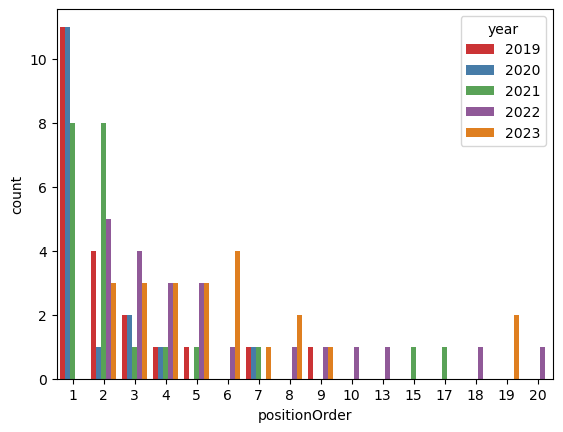

In [267]:
sns.countplot(data=driver_results, x='positionOrder', hue='year', palette='Set1')

In [268]:
results.shape[0], results.driverId.nunique()

(2080, 33)

In [273]:
results.position.nunique()

21

In [274]:
# ### Example 5x5 Transition Matrix (Previous position -> Current position)
#  Rows: previous position (0 to 4), Columns: next position (0 to 4)
#  Values: number of transitions observed in data

#         |   0   |   1   |   2   |   3   |   4
#    -----------------------------------------------
#    0    |  12   |   9   |   2   |   1   |   3
#    1    |   4   |  11   |   7   |   0   |   2
#    2    |   1   |   2   |   8   |   5   |   4
#    3    |   0   |   0   |   2   |   6   |   3
#    4    |   2   |   1   |   1   |   2   |   5
 
#  (Table above is a static demonstration. To generate a transition matrix with your real data, see instructions in further cells.)

In [ ]:
model_data = defaultdict(lambda: defaultdict())
grouped_results = results.sort_values('round').groupby('year')

for year, group in grouped_results:
    drivers = group['driverId'].unique()
    for driver in drivers:
        driver_results = group.loc[group['driverId'] == driver]
        previous_positions = np.insert(driver_results['position'].values[:-1], 0, 'START')
        model_data[year][int(driver)] = {'positions': driver_results['position'].values}



In [270]:
model_data[2023][844]

{'position': array([ 0,  7,  0,  3,  7,  6, 11,  4,  2,  9,  7,  3,  0,  4,  4,  4,  5,
         0,  3,  0,  2,  2]),
 'previous_positions': array([-1,  0,  7,  0,  3,  7,  6, 11,  4,  2,  9,  7,  3,  0,  4,  4,  4,
         5,  0,  3,  0,  2])}

In [271]:
model_data[2022]

defaultdict(None,
            {832: {'position': array([2, 3, 0, 0, 3, 4, 2, 0, 2, 1, 0, 5, 4, 3, 8, 4, 3, 0, 0, 5, 3, 4]),
              'previous_positions': array([-1,  2,  3,  0,  0,  3,  4,  2,  0,  2,  1,  0,  5,  4,  3,  8,  4,
                      3,  0,  0,  5,  3])},
             815: {'position': array([18,  4,  2,  2,  4,  2,  1,  2,  0,  2,  0,  4,  5,  2,  5,  6,  1,
                      2,  4,  3,  7,  3]),
              'previous_positions': array([-1, 18,  4,  2,  2,  4,  2,  1,  2,  0,  2,  0,  4,  5,  2,  5,  6,
                      1,  2,  4,  3,  7])},
             807: {'position': array([17, 12]),
              'previous_positions': array([-1, 17])},
             849: {'position': array([16,  0, 16, 16, 14, 16, 15, 15, 16, 12,  0,  0, 18, 18, 18, 15,  0,
                      9, 17, 18, 16, 19]),
              'previous_positions': array([-1, 16,  0, 16, 16, 14, 16, 15, 15, 16, 12,  0,  0, 18, 18, 18, 15,
                      0,  9, 17, 18, 16])},
           

In [ ]:
def parse_results(results):
    

In [141]:
results['position'].unique()

<StringArray>
[ '1',  '2',  '3',  '4',  '5',  '6',  '7',  '8',  '9', '10', '11', '12', '13',
 '\N', '14', '15', '16', '17', '18', '19', '20']
Length: 21, dtype: str

In [140]:
driver_results['position'].unique()

<StringArray>
['4', '1', '2', '7', '3', '15', '\N', '5', '10', '13', '6', '8', '9', '18',
 '12']
Length: 15, dtype: str